<a href="https://colab.research.google.com/github/feridehmedovv200/OIBSIP/blob/main/DataScience-L2-HousePricePrediction/house_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Dataset Summary ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB
None

--- Missing Values Check ---
Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

--- Descriptive Statistics ---
                Id         Area     Bedrooms   Bathrooms       Floors  \
count  2000.000000  2000.000000  2000.000000  

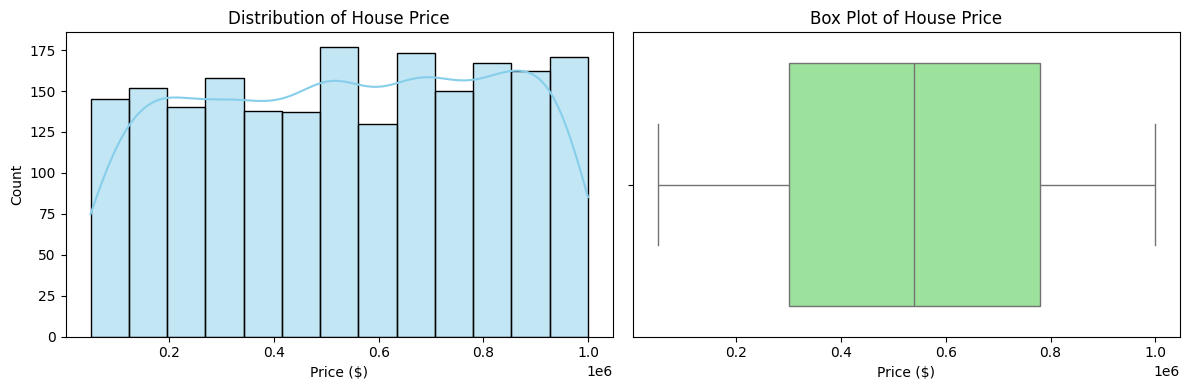

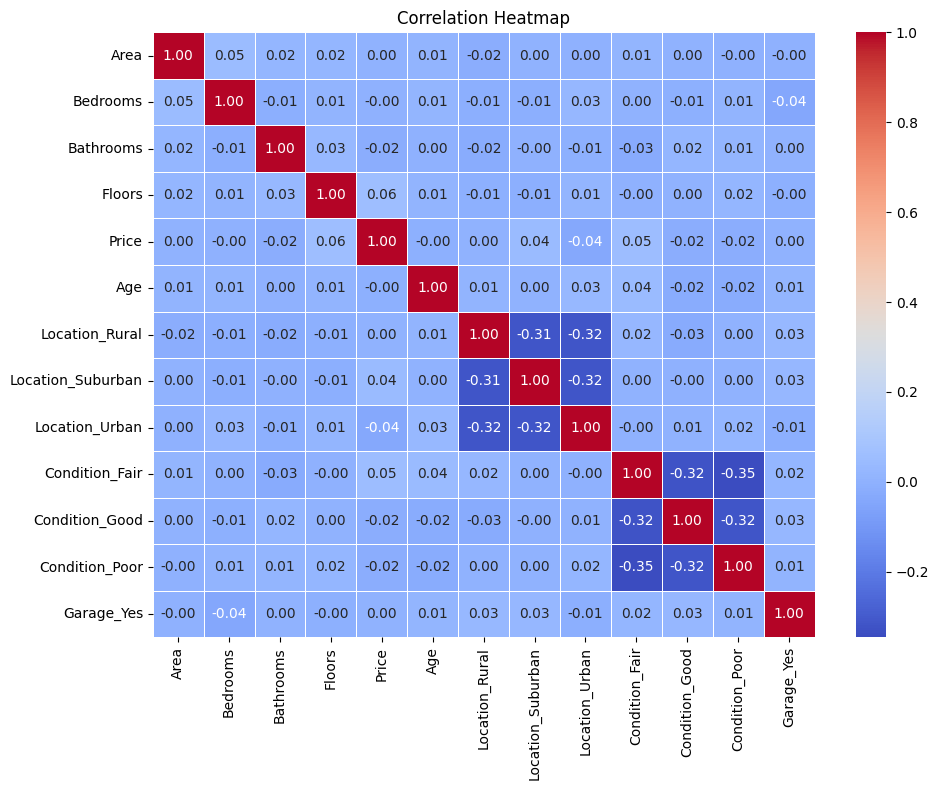


--- Linear Regression Performance ---
Train MSE: 75,258,376,501.24 | RMSE: 274,332.60 | R²: 0.0099
Test MSE:  78,321,466,146.03 | RMSE: 279,859.73 | R²: -0.0067


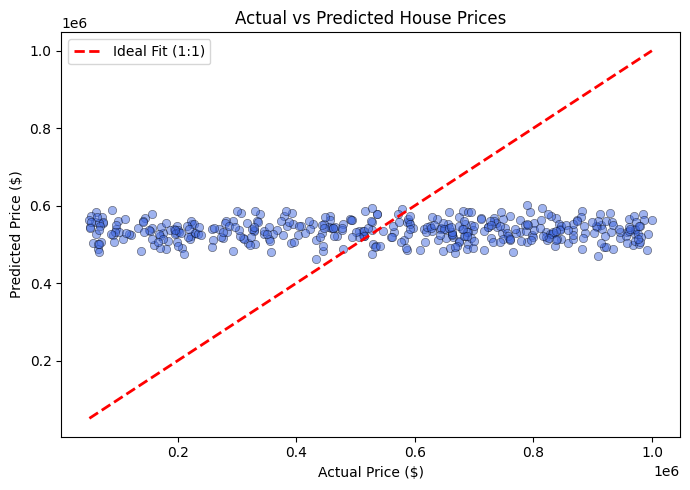

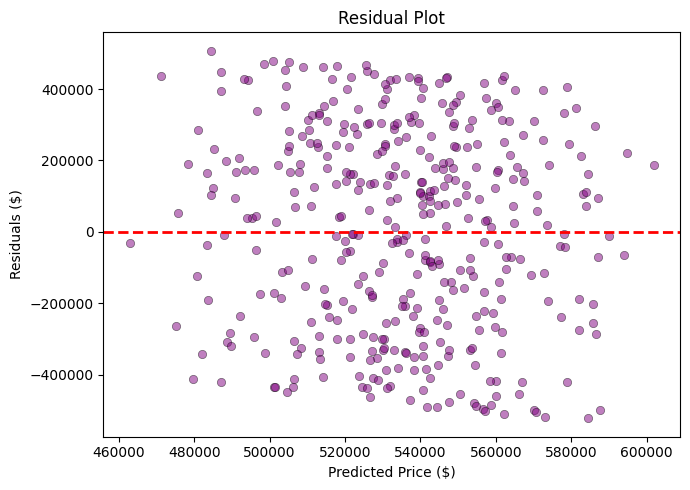


--- Model Coefficients ---
          Feature   Coefficient
   Condition_Fair  24083.307846
           Floors  23727.983633
Location_Suburban  11511.989815
   Condition_Poor   4073.268930
       Garage_Yes   2373.530579
   Location_Rural   1317.542020
         Bedrooms     76.784827
             Area     -0.575754
              Age   -117.613885
        Bathrooms  -9662.248234
   Location_Urban -12718.918912
   Condition_Good -12941.044835


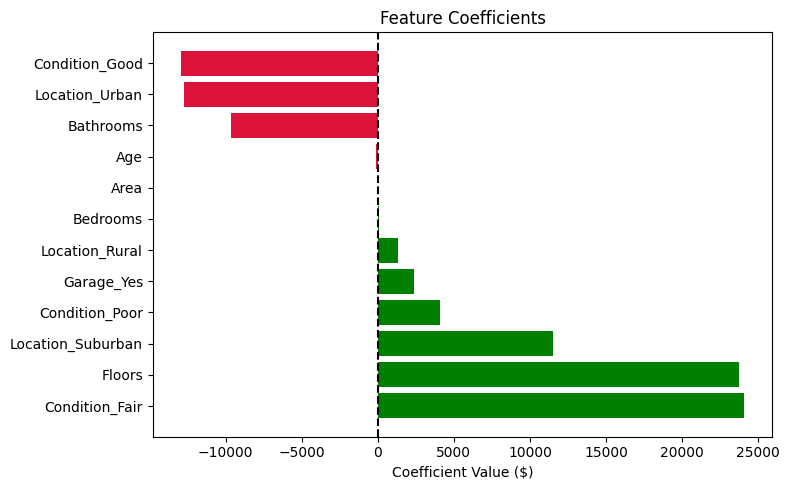


--- Regularization Models Comparison (Test Set) ---
Linear Regression - RMSE: 279,859.73 | R²: -0.0067
Ridge Regression     - RMSE: 279,858.42 | R²: -0.0067
Lasso Regression     - RMSE: 279,834.95 | R²: -0.0065


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. LOAD DATASET & PERFORM EDA
# ==========================================
df = pd.read_csv("House Price Prediction Dataset.csv")

print("--- Dataset Summary ---")
print(df.info())
print("\n--- Missing Values Check ---")
print(df.isnull().sum())
print("\n--- Descriptive Statistics ---")
print(df.describe())

# Target Variable Distribution
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['Price'], kde=True, color='skyblue')
plt.title('Distribution of House Price')
plt.xlabel('Price ($)')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['Price'], color='lightgreen')
plt.title('Box Plot of House Price')
plt.xlabel('Price ($)')
plt.tight_layout()
plt.show()

# ==========================================
# 2. FEATURE ENGINEERING & CATEGORICAL ENCODING
# ==========================================
# Age feature derivation
df['Age'] = 2026 - df['YearBuilt']

# Drop non-predictive identifier and original YearBuilt
df_model = df.drop(columns=['Id', 'YearBuilt'])

# One-Hot Encoding for categorical features (drop_first=True to avoid dummy variable trap)
df_encoded = pd.get_dummies(df_model, columns=['Location', 'Condition', 'Garage'], drop_first=True)

# ==========================================
# 3. CORRELATION ANALYSIS
# ==========================================
plt.figure(figsize=(10, 8))
sns.heatmap(df_encoded.corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# ==========================================
# 4. TRAIN / TEST SPLIT (80/20)
# ==========================================
X = df_encoded.drop(columns=['Price'])
y = df_encoded['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# ==========================================
# 5. TRAIN LINEAR REGRESSION MODEL
# ==========================================
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# ==========================================
# 6. MODEL EVALUATION
# ==========================================
mse_train = mean_squared_error(y_train, y_pred_train)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, y_pred_train)

mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_pred_test)

print("\n--- Linear Regression Performance ---")
print(f"Train MSE: {mse_train:,.2f} | RMSE: {rmse_train:,.2f} | R²: {r2_train:.4f}")
print(f"Test MSE:  {mse_test:,.2f} | RMSE: {rmse_test:,.2f} | R²: {r2_test:.4f}")

# ==========================================
# 7. SCATTER PLOT: ACTUAL VS PREDICTED
# ==========================================
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_test, alpha=0.5, color='royalblue', edgecolors='k', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Fit (1:1)')
plt.title('Actual vs Predicted House Prices')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.legend()
plt.tight_layout()
plt.show()

# ==========================================
# 8. RESIDUAL PLOT
# ==========================================
residuals = y_test - y_pred_test
plt.figure(figsize=(7, 5))
plt.scatter(y_pred_test, residuals, alpha=0.5, color='purple', edgecolors='k', linewidth=0.5)
plt.axhline(0, color='red', linestyle='--', lw=2)
plt.title('Residual Plot')
plt.xlabel('Predicted Price ($)')
plt.ylabel('Residuals ($)')
plt.tight_layout()
plt.show()

# ==========================================
# 9. COEFFICIENT ANALYSIS
# ==========================================
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

print("\n--- Model Coefficients ---")
print(coef_df.to_string(index=False))

plt.figure(figsize=(8, 5))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=np.where(coef_df['Coefficient'] > 0, 'green', 'crimson'))
plt.axvline(0, color='black', linestyle='--')
plt.title('Feature Coefficients')
plt.xlabel('Coefficient Value ($)')
plt.tight_layout()
plt.show()

# ==========================================
# 10. (BONUS) RIDGE & LASSO REGULARIZATION
# ==========================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Ridge Model
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

# Lasso Model
lasso = Lasso(alpha=100.0)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)

print("\n--- Regularization Models Comparison (Test Set) ---")
print(f"Linear Regression - RMSE: {rmse_test:,.2f} | R²: {r2_test:.4f}")
print(f"Ridge Regression     - RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_ridge)):,.2f} | R²: {r2_score(y_test, y_pred_ridge):.4f}")
print(f"Lasso Regression     - RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lasso)):,.2f} | R²: {r2_score(y_test, y_pred_lasso):.4f}")